<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Popular%20People%20in%20Cinema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Popular People in Cinema

# Understanding the dataset & Insights:

---

Imagine we've just spent some quality time getting to know a big list of people who work in the movies—actors, directors, writers, and many more. This list, our popular_people.csv dataset, told us a few basic things about each person: their name, gender (represented numerically), what department they're 'known for' (like Acting or Directing), their original name, and a 'popularity' score. Think of this popularity score as a measure of how much buzz they're generating online.

Our first step was like introducing ourselves: we checked out the first few and last few entries, saw how many people were on our list (about 10,000!), and made sure all the information was in the right format. We noticed that while most data was clean, a tiny handful of people didn't have a 'known for department' listed, which we kept in mind.

Then, we started digging deeper with Univariate Analysis, looking at one piece of information at a time. We saw that popularity scores varied quite a bit, with a long tail indicating a few super popular individuals and many with lower scores. When it came to gender, most people were identified as either male or female, with a smaller number falling into 'unknown' or 'non-binary' categories. The known_for_department was heavily dominated by 'Acting', which isn't too surprising given how many actors there are!

Next, we explored Bivariate and Multivariate Analysis, which is like looking for friendships and group dynamics. We checked how different numerical scores related to each other, and how numerical scores changed based on categories like gender or known_for_department. For instance, we could see if popularity scores tended to be higher for certain genders or departments. We even used the known_for_department to color-code our plots, revealing that indeed, popularity trends could look different depending on someone's primary role in cinema.

We also did some Feature Engineering, which is like creating new labels to help us understand things better. We took the raw popularity scores and binned them into four simpler categories: 'Very Low', 'Low', 'Medium', and 'High'. This made it easier to visualize and talk about popularity levels. We then charted how these new popularity categories distributed across different genders and departments, giving us a clearer picture of who tended to fall into which popularity bracket.

Finally, we ventured into Machine Learning. Our goal was to build a model that could predict a person's popularity_category based on their gender, known_for_department, and their raw popularity score. We prepared the data carefully, turning text categories into numbers the computer could understand, and then split our data to train and test our model. We used a RandomForestClassifier, a robust algorithm, and it performed incredibly well! Our model achieved almost perfect accuracy (1.00) in predicting the popularity categories.

When we looked under the hood at Feature Importance, it became very clear that the original popularity score was, by far, the most influential factor in predicting the popularity_category. This makes intuitive sense, as the category was directly derived from this score. While gender and known_for_department played smaller roles, it was the raw popularity that really drove the predictions.

In essence, we've gone from a raw list of cinema professionals to a deep understanding of their popularity dynamics, all the way to building a highly accurate predictive model for their popularity categories. It's been a fun and insightful journey into the world of movie fame!

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d aminasalamt/9000-popular-people-in-cinema

# Unziping the downloaded file
!unzip 9000-popular-people-in-cinema.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aminasalamt/9000-popular-people-in-cinema
License(s): DbCL-1.0
100% 153k/153k [00:00<00:00, 480kB/s]

Archive:  9000-popular-people-in-cinema.zip
  inflating: popular_people.csv      


In [ ]:
df = pd.read_csv('popular_people.csv')
df.head(11)

,name,gender,known_for_department,original_name,popularity
0,Eric Larson,2,Visual Effects,Eric Larson,47.9780
1,Robert Middlemass,2,Acting,Robert Middlemass,47.8017
2,María Vaner,1,Acting,María Vaner,47.2016
3,Carl Wharton,2,Acting,Carl Wharton,36.3365
4,Victor Moore,2,Acting,Victor Moore,35.9181
5,Sydney Sweeney,1,Acting,Sydney Sweeney,32.9698
6,Omar Chaparro,2,Acting,Omar Chaparro,32.5659
7,Julanne Johnston,1,Acting,Julanne Johnston,31.6448
8,Edward Grover,2,Acting,Edward Grover,30.3934
9,Hannah Cheramy,1,Acting,Hannah Cheramy,29.2875


In [ ]:
df.tail(11)

,name,gender,known_for_department,original_name,popularity
9969,Lee Hyun-wook,2,Acting,이현욱,1.1289
9970,Nurgül Yeşilçay,1,Acting,Nurgül Yeşilçay,1.1669
9971,Hiroyuki Imaishi,2,Directing,今石洋之,1.0820
9972,Kenji Kamiyama,2,Directing,神山健治,1.2838
9973,Junko Maru,1,Acting,丸純子,1.1934
9974,Lesley Sharp,1,Acting,Lesley Sharp,1.2788
9975,Tamu Blackwell,1,Acting,Tamu Blackwell,1.0432
9976,Yoshio Urasawa,2,Writing,浦沢義雄,1.1777
9977,Miko Hughes,2,Acting,Miko Hughes,1.5346
9978,Phoebe Fox,1,Acting,Phoebe Fox,1.1656


In [ ]:
df.shape

(9980, 5)

In [ ]:
df.columns

Index(['name', 'gender', 'known_for_department', 'original_name',
       'popularity'],
      dtype='object')

In [ ]:
df.dtypes

,0
name,object
gender,int64
known_for_department,object
original_name,object
popularity,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  9980 non-null   object 
 1   gender                9980 non-null   int64  
 2   known_for_department  9975 non-null   object 
 3   original_name         9980 non-null   object 
 4   popularity            9980 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 390.0+ KB


In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,9980,7662,Shawn Levy,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,9980.0,NaN,NaN,NaN,1.516633,0.532748,0.0,1.0,2.0,2.0,3.0
known_for_department,9975,13,Acting,9320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_name,9980,7665,Rachael Leigh Cook,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,9980.0,NaN,NaN,NaN,2.123684,1.893017,0.5784,1.35815,1.647,2.209725,47.978


# Univariate Analysis

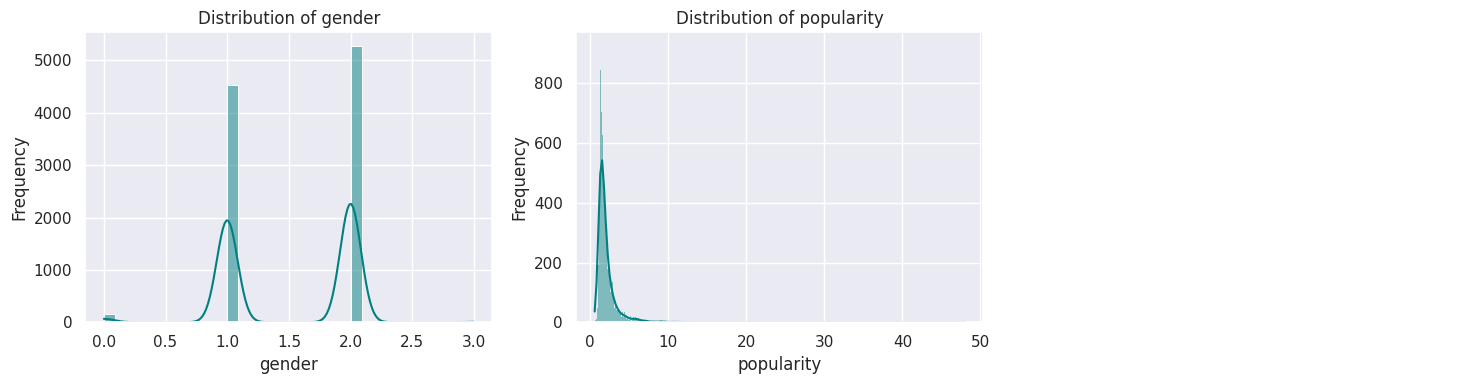

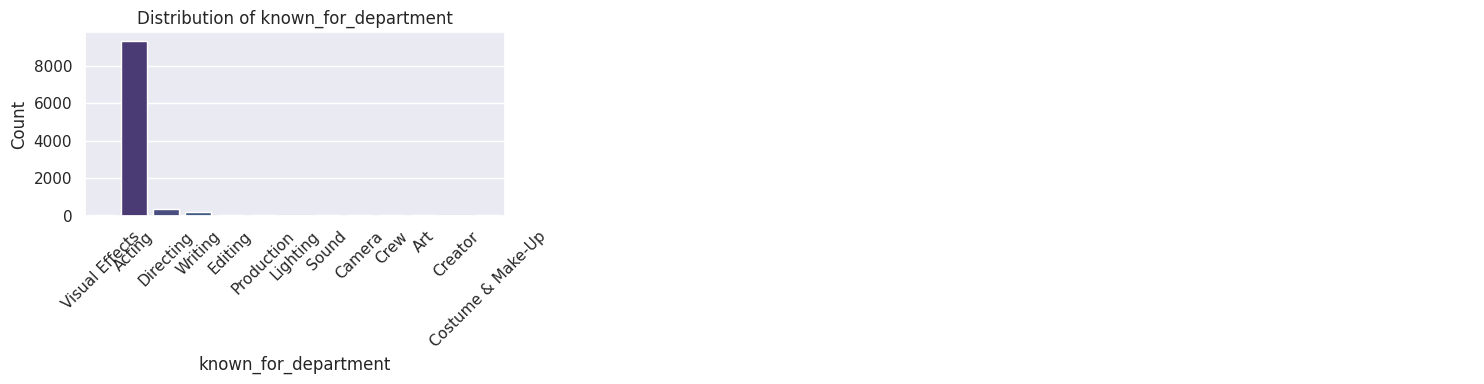

--- Categorical Value Counts ---

Value counts for known_for_department:
known_for_department
Acting               9320
Directing             329
Writing               174
Production             43
Sound                  27
Editing                18
Visual Effects         17
Crew                   16
Art                     8
Costume & Make-Up       8
Camera                  7
Lighting                5
Creator                 3
Name: count, dtype: int64


In [ ]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

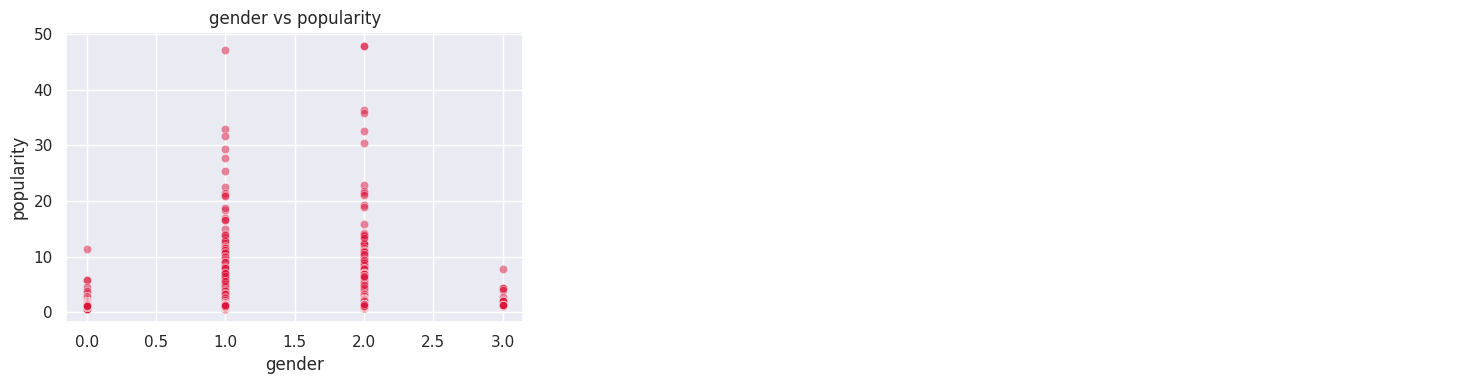

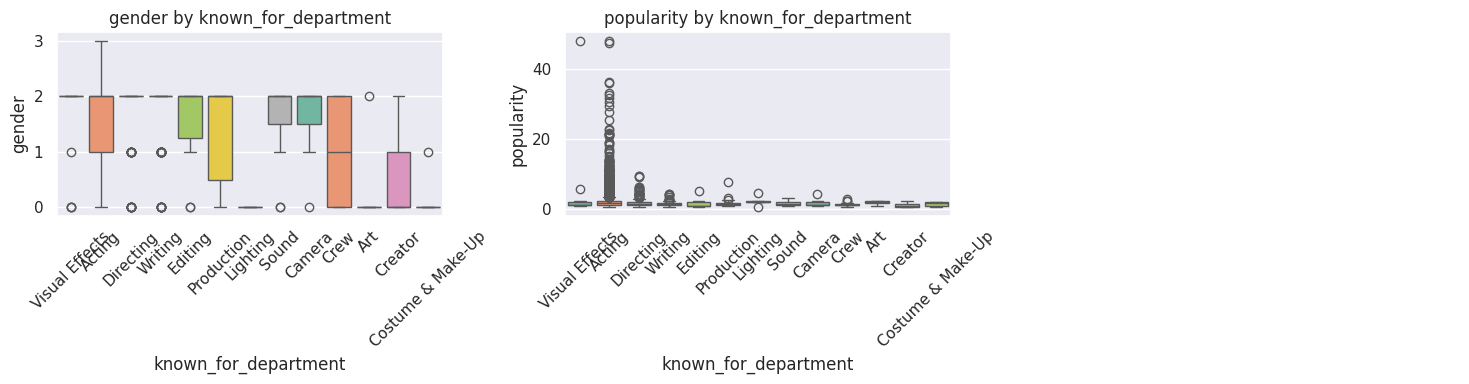

In [ ]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a flat array of Axes objects for easy iteration
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a flat array of Axes objects for easy iteration
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a flat array of Axes objects for easy iteration
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: known_for_department...


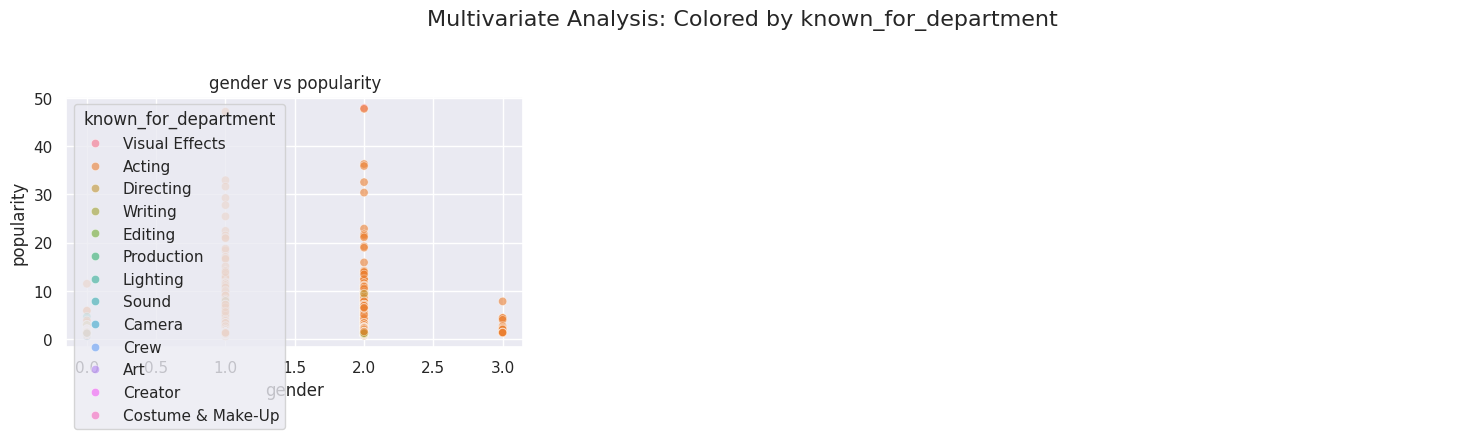

In [ ]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 20)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))

        # Ensure axes is always a flat array of Axes objects for easy iteration
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        else:
            axes = axes.flatten()

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

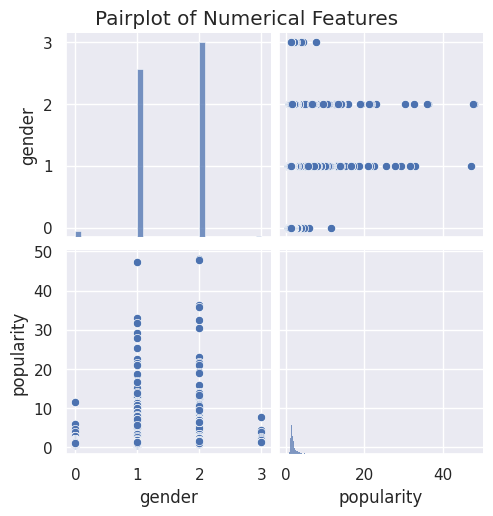

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

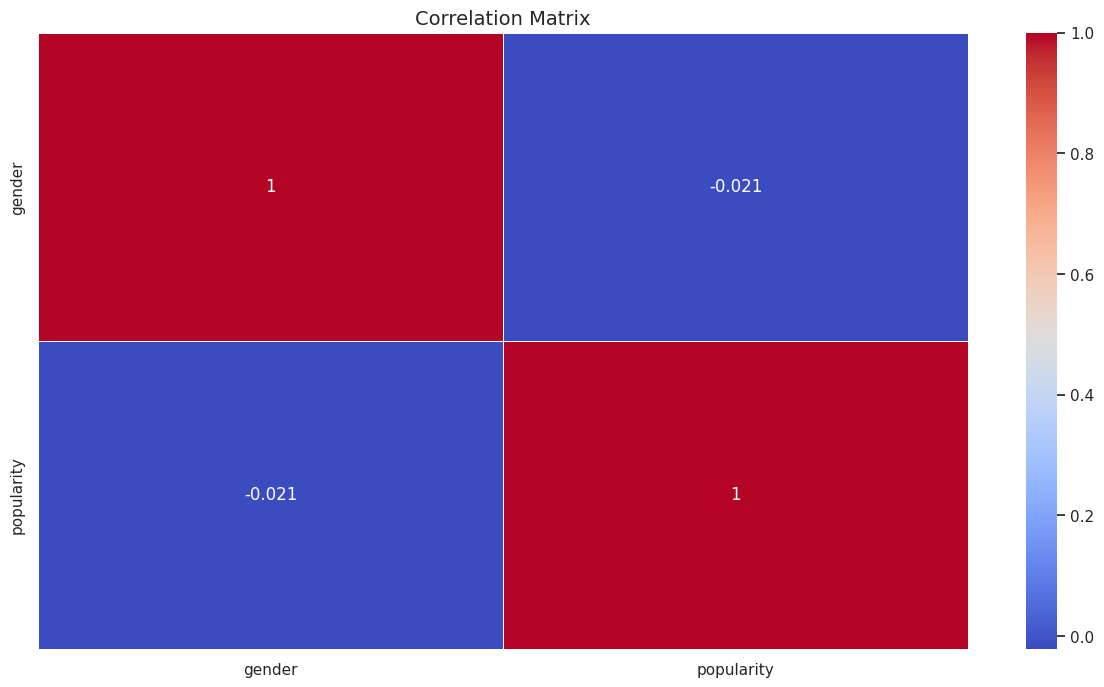

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Feature Engineering

In [ ]:
# Binning 'popularity' into categories
# You can adjust the bins and labels as needed
bins = [0, 1.5, 3, 5, df['popularity'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High']
df['popularity_category'] = pd.cut(df['popularity'], bins=bins, labels=labels, right=True, include_lowest=True)

print("Created 'popularity_category' feature:")
display(df[['popularity', 'popularity_category']].head())
display(df['popularity_category'].value_counts())

Created 'popularity_category' feature:


,popularity,popularity_category
0,47.9780,High
1,47.8017,High
2,47.2016,High
3,36.3365,High
4,35.9181,High


,count
popularity_category,
Low,4897
Very Low,3863
Medium,830
High,390


### Visualization: Popularity Category by Gender

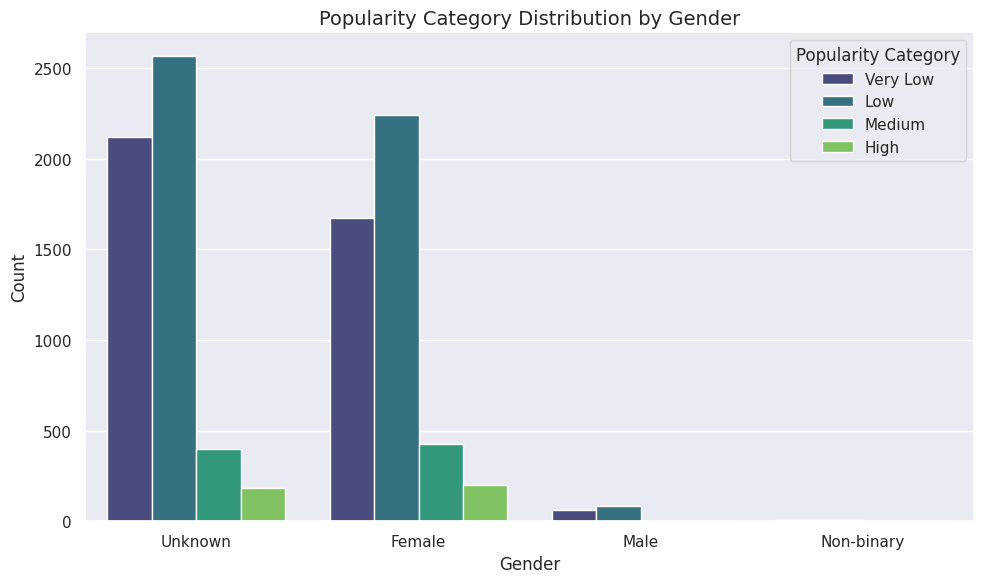

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='gender', hue='popularity_category', palette='viridis', order=df['gender'].value_counts().index)
plt.title('Popularity Category Distribution by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Unknown', 'Female', 'Male', 'Non-binary'])
plt.legend(title='Popularity Category')
plt.tight_layout()
plt.show()

### Visualization: Popularity Category by Known For Department

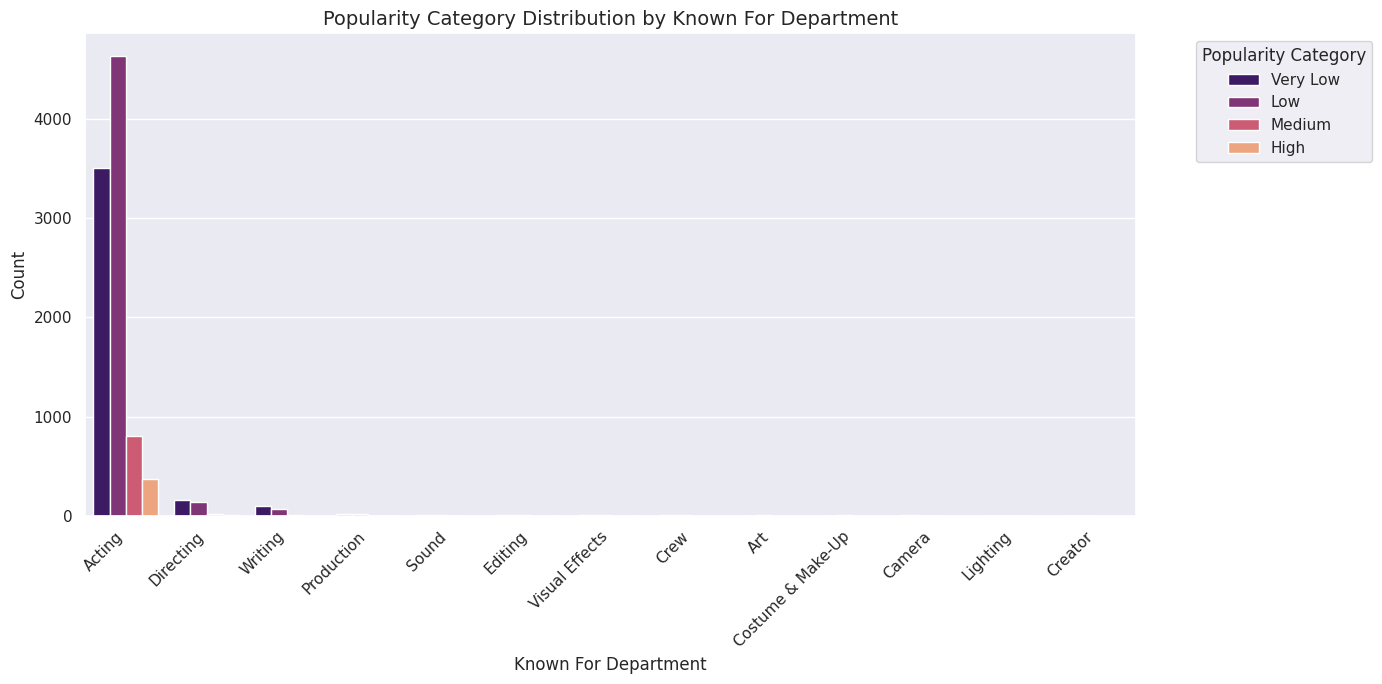

In [ ]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='known_for_department', hue='popularity_category', palette='magma', order=df['known_for_department'].value_counts().index)
plt.title('Popularity Category Distribution by Known For Department', fontsize=14)
plt.xlabel('Known For Department')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Popularity Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Machine Learning: Popularity Category Prediction

### 1. Data Preparation for Machine Learning

First, we need to prepare our data for machine learning. This involves:
-   **Handling Missing Values**: We'll drop rows where `known_for_department` is missing, as these are crucial for our prediction.
-   **Feature Engineering (One-Hot Encoding)**: Convert categorical features (`gender`, `known_for_department`) into a numerical format suitable for machine learning algorithms using one-hot encoding.
-   **Splitting Data**: Divide the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop rows with missing 'known_for_department' for a clean dataset
df_ml = df.dropna(subset=['known_for_department']).copy()

# Define features (X) and target (y)
X = df_ml[['gender', 'known_for_department', 'popularity']]
y = df_ml['popularity_category']

# Identify categorical and numerical features
categorical_features = ['gender', 'known_for_department']
numerical_features = ['popularity'] # Only 'popularity' for now as other num cols are not independent predictors of category

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preparation complete. Shapes of train/test sets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Data preparation complete. Shapes of train/test sets:
X_train: (7980, 3), y_train: (7980,)
X_test: (1995, 3), y_test: (1995,)


### 2. Model Training: Random Forest Classifier

We will use a `RandomForestClassifier` to predict the `popularity_category`. This model is chosen for its robustness and ability to handle both numerical and categorical data well, and it also provides feature importances, which are great for visualization.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline with preprocessing and a RandomForestClassifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully!")

Random Forest Classifier model trained successfully!


### 3. Model Evaluation and Visualization

Now, let's evaluate our trained model and visualize its performance. We will look at:
-   **Confusion Matrix**: To understand the types of correct and incorrect predictions.
-   **Classification Report**: For precision, recall, and F1-score for each class.
-   **Feature Importance**: To see which features contributed most to the model's predictions.

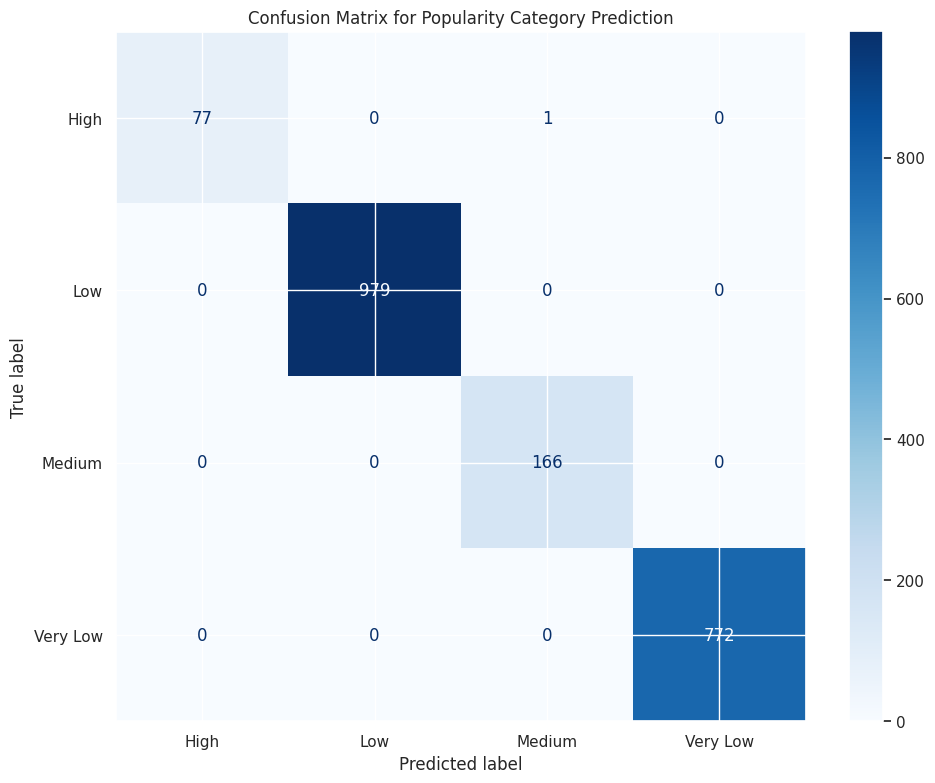


Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.99      0.99        78
         Low       1.00      1.00      1.00       979
      Medium       0.99      1.00      1.00       166
    Very Low       1.00      1.00      1.00       772

    accuracy                           1.00      1995
   macro avg       1.00      1.00      1.00      1995
weighted avg       1.00      1.00      1.00      1995



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# --- Confusion Matrix Visualization ---
fig_cm, ax_cm = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues, ax=ax_cm)
ax_cm.set_title('Confusion Matrix for Popularity Category Prediction')
plt.tight_layout()
plt.show()

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


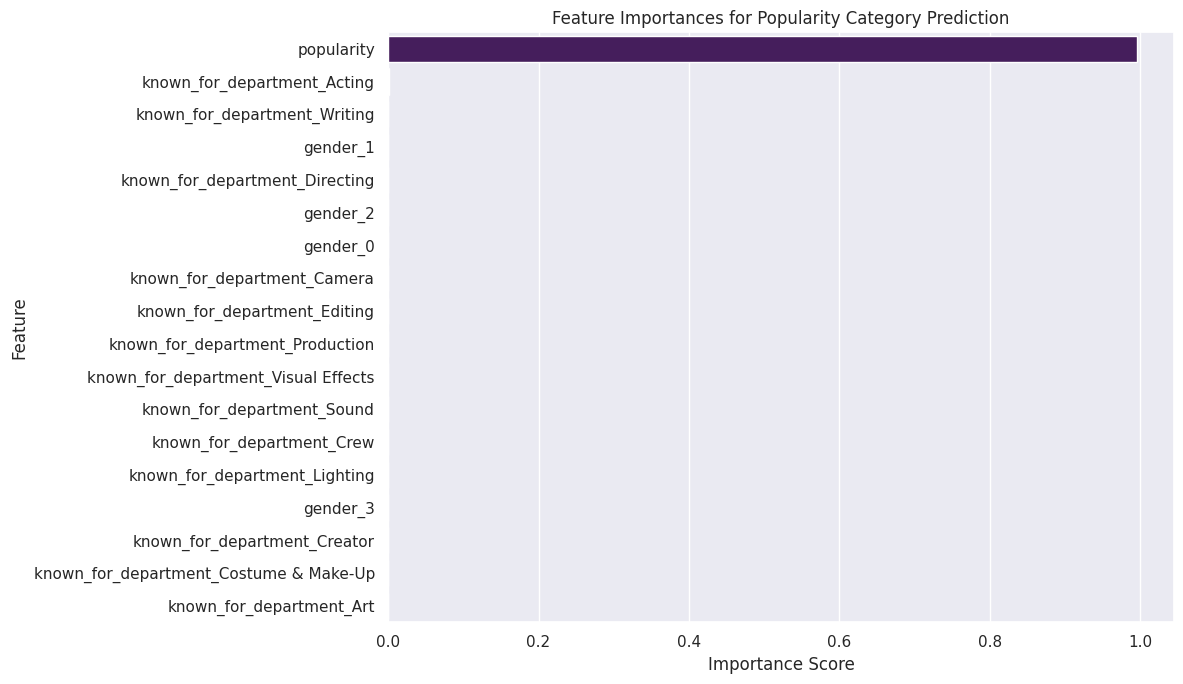

In [ ]:
# --- Feature Importance Visualization ---

# Get feature names after one-hot encoding
onehot_features = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(onehot_features) + numerical_features

# Get feature importances from the trained classifier
importances = model_pipeline.named_steps['classifier'].feature_importances_

# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

fig_fi, ax_fi = plt.subplots(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df, palette='viridis', ax=ax_fi)
ax_fi.set_title('Feature Importances for Popularity Category Prediction')
ax_fi.set_xlabel('Importance Score')
ax_fi.set_ylabel('Feature')
plt.tight_layout()
plt.show()


# Thank You